# 2- Exploratory Data Analysis (EDA) and Modeling Notebook

**Purpose:**  
This notebook is dedicated to performing all Exploratory Data Analysis (EDA) and machine learning modeling steps for the machine failure prediction project. The goal is to extract actionable insights and build predictive models to identify potential failures one day before they occur.

**Data Source:**  
All analyses in this notebook use the previously cleaned and merged dataset (`df_merged.csv`), which includes both features and labels, covering the necessary historical data for accurate modeling.

**Main Steps Covered in This Notebook:**
1. **Initial Data Overview:**  
   - Load the merged dataset and review its structure, data types, and basic statistics.
2. **Exploratory Data Analysis (EDA):**  
   - Univariate and bivariate analysis of key features.
   - Detect and visualize patterns, trends, and potential issues (outliers, missing values, imbalances).
3. **Feature Engineering:**  
   - Identify and construct new features if needed, based on domain knowledge or EDA findings.
4. **Data Preparation:**  
   - Final data cleaning steps, handling missing values, and encoding if required.
   - Splitting the data into train and test sets.
5. **Model Building:**  
   - Train baseline and advanced machine learning models for failure prediction.
   - Evaluate model performance using appropriate metrics (e.g., ROC-AUC, precision, recall).
6. **Business and Technical Insights:**  
   - Summarize key findings and recommendations for business stakeholders.

**Assumptions:**  
- The input data (`df_merged.csv`) is already cleaned and properly merged.
- All further work is reproducible from this notebook, starting from the loaded data file.

---



In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import os
from datetime import datetime
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models & utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Warnings handling
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)


###   step 1: Load the cleaned merged dataset for EDA and modeling and create directory for saving plots 

In [2]:
#create the director for saving plots
os.makedirs(r'C:\Users\20111\OneDrive - Faculty Of Business (Ain Shams University)\Documents\Vdafone analysis\New folder/ubuntu/eda_analysis/plots',exist_ok=True)
#Set the style for every plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')


In [3]:
# Load data
df = pd.read_csv('df_merged.csv')
df.head()

,date,x1_count,x2_count,x3_count,x4_count,x5_count,x6_count,x6_mean,x6_max,x6_min,x6_std,x7_count,x8_count,x8_mean,x8_max,x8_min,x8_std,x9_count,x9_mean,x9_max,x9_min,x9_std,x10_count,x11_count,x12_count,x13_count,x14_count,x14_mean,x14_max,x14_min,x14_std,x15_count,x15_mean,x15_max,x15_min,x15_std,x16_count,x17_count,x17_mean,x17_max,x17_min,x17_std,x18_count,x19_count,x20_count,x21_count,x22_count,x23_count,x24_count,x25_count,x26_count,label
0,03/05/2015,0,0,0,0,0,0,78919.69565,9245.434783,41220.65217,14040.78261,0,0,72822.0,10556.0,44361.0,0.0,0,75800.73913,13898.69565,50125.56522,22548.34783,0,0,0,0,0,73570.0,11871.0,44580.0,0.0,0,75800.73913,13898.69565,50125.56522,22548.34783,0,0,83956.82609,489.739130,16591.43478,12425.60870,0,0,0,0,0,0,0,0,0,0
1,04/05/2015,0,0,0,0,0,0,78785.34783,9482.217391,41109.82609,14709.39130,0,0,72822.0,10556.0,44361.0,0.0,0,77218.86957,14372.34783,51881.78261,23065.17391,0,0,0,0,0,73570.0,11871.0,44580.0,0.0,0,77218.86957,14372.34783,51881.78261,23065.17391,0,0,84074.91304,274.869565,15347.21739,13017.30435,0,0,0,0,0,0,0,0,0,0
2,05/05/2015,0,0,0,0,0,1700,78651.00000,9719.000000,40999.00000,15378.00000,0,2,72822.0,10556.0,44361.0,0.0,5,78637.00000,14846.00000,53638.00000,23582.00000,0,0,0,0,2,73570.0,11871.0,44580.0,0.0,5,78637.00000,14846.00000,53638.00000,23582.00000,0,2421,84193.00000,60.000000,14103.00000,13609.00000,0,0,0,0,0,0,0,0,0,0
3,06/05/2015,0,0,0,0,0,1978,62134.00000,1295.000000,38893.00000,20331.00000,0,24,41061.0,1290.0,29703.0,12609.0,11,62046.00000,1213.00000,26671.00000,16166.00000,0,0,3,1,24,41061.0,1290.0,29703.0,12609.0,11,62045.00000,1213.00000,26671.00000,16166.00000,0,1738,86366.00000,2060.000000,41129.00000,11652.00000,0,0,0,0,0,0,0,0,0,0
4,07/05/2015,0,0,0,0,0,1832,73245.00000,129.000000,53549.00000,11973.00000,0,2,72822.0,10556.0,44361.0,0.0,3,74070.00000,10580.00000,45219.00000,0.00000,0,0,0,0,2,73570.0,11871.0,44580.0,0.0,3,74020.00000,10591.00000,44182.00000,0.00000,0,397,76982.00000,1455.000000,39785.00000,20259.00000,0,0,0,0,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 52 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       514 non-null    object 
 1   x1_count   514 non-null    int64  
 2   x2_count   514 non-null    int64  
 3   x3_count   514 non-null    int64  
 4   x4_count   514 non-null    int64  
 5   x5_count   514 non-null    int64  
 6   x6_count   514 non-null    int64  
 7   x6_mean    514 non-null    float64
 8   x6_max     514 non-null    float64
 9   x6_min     514 non-null    float64
 10  x6_std     514 non-null    float64
 11  x7_count   514 non-null    int64  
 12  x8_count   514 non-null    int64  
 13  x8_mean    514 non-null    float64
 14  x8_max     514 non-null    float64
 15  x8_min     514 non-null    float64
 16  x8_std     514 non-null    float64
 17  x9_count   514 non-null    int64  
 18  x9_mean    514 non-null    float64
 19  x9_max     514 non-null    float64
 20  x9_min    

In [5]:
#Convert date column to datetime
df['date']=pd.to_datetime(df['date'],format='%d/%m/%Y')
df['date'].dtypes

dtype('<M8[ns]')

In [6]:
# Print basic info about the dataset
print(f'df shape:{df.shape}')
print(f'Number of Failures (label=1):{df['label'].sum()}')
print (f'Failure rate :{df['label'].mean()*100:.2f}%')
print (f'date range :{df['date'].min().strftime('%d/%m/%Y')} to {df['date'].max().strftime('%d/%m/%Y')}')

df shape:(514, 52)
Number of Failures (label=1):25
Failure rate :4.86%
date range :03/05/2015 to 05/10/2016


In [7]:
count_col=[col for col in df.columns if 'count' in col]
summary=[]
for col in count_col:
    summary.append({'column':col,
                    'min':df[col].min(),
                    'max':df[col].max()})
summary_df=pd.DataFrame(summary)
summary_df


,column,min,max
0,x1_count,0,29
1,x2_count,0,5
2,x3_count,0,0
3,x4_count,0,26
4,x5_count,0,3
5,x6_count,0,4725
6,x7_count,0,0
7,x8_count,0,67
8,x9_count,0,43
9,x10_count,0,1


In [8]:
#save the processed dataframe
df.to_csv(r'C:\Users\20111\OneDrive - Faculty Of Business (Ain Shams University)\Documents\Vdafone analysis\New folder/ubuntu/eda_analysis/df_processed.csv',index=False)

In [9]:
#Identify all summary statistics columns and group them 
Numerical_col=[ col for col in df.columns if any(stat in col for stat in ['mean','count','max','min','std'])]

In [10]:
# Change the datatype of dataset to be all intger  
df[Numerical_col]=df[Numerical_col].astype(int)
#Convert label column to category datatype
df['label']=df['label'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 52 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       514 non-null    datetime64[ns]
 1   x1_count   514 non-null    int32         
 2   x2_count   514 non-null    int32         
 3   x3_count   514 non-null    int32         
 4   x4_count   514 non-null    int32         
 5   x5_count   514 non-null    int32         
 6   x6_count   514 non-null    int32         
 7   x6_mean    514 non-null    int32         
 8   x6_max     514 non-null    int32         
 9   x6_min     514 non-null    int32         
 10  x6_std     514 non-null    int32         
 11  x7_count   514 non-null    int32         
 12  x8_count   514 non-null    int32         
 13  x8_mean    514 non-null    int32         
 14  x8_max     514 non-null    int32         
 15  x8_min     514 non-null    int32         
 16  x8_std     514 non-null    int32         
 1

In [11]:
##quick info about numerical columns
df[Numerical_col].describe ().T

,count,mean,std,min,25%,50%,75%,max
x1_count,514.0,0.396887,2.079809,0.0,0.00,0.0,0.00,29.0
x2_count,514.0,0.021401,0.244888,0.0,0.00,0.0,0.00,5.0
x3_count,514.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0
x4_count,514.0,0.171206,1.743232,0.0,0.00,0.0,0.00,26.0
x5_count,514.0,0.040856,0.242397,0.0,0.00,0.0,0.00,3.0
x6_count,514.0,228.167315,728.163148,0.0,0.00,0.0,9.00,4725.0
x6_mean,514.0,78603.912451,7770.105914,33211.0,75073.75,81337.0,83899.75,86388.0
x6_max,514.0,9466.147860,11805.375234,25.0,2690.25,4273.0,9916.00,54492.0
x6_min,514.0,44859.215953,10809.385454,8490.0,40682.75,43548.0,48754.25,79580.0
x6_std,514.0,17078.745136,8518.249861,0.0,10930.75,18080.5,23765.75,33983.0


> As we can see  most of the dataset have outliers 

In [12]:
#count failures over the period
label_date=df.groupby('date')['label'].apply(lambda x : (x== 1).sum()).reset_index()
# Cumulative sum over time
label_date['cumulative_failures'] = label_date['label'].cumsum()
print(label_date['date'])

0     2015-05-03
1     2015-05-04
2     2015-05-05
3     2015-05-06
4     2015-05-07
         ...    
509   2016-10-01
510   2016-10-02
511   2016-10-03
512   2016-10-04
513   2016-10-05
Name: date, Length: 514, dtype: datetime64[ns]


In [13]:
#Count failure by date
Label_date = df.groupby('date')['label'].apply(lambda x: (x == 1).sum()).reset_index()

#Rename the new column
#label_date = label_date.rename(columns={'label': 'failures_count'})

# cumulative sum للـ failures
Label_date['cumulative_failures'] = Label_date['label'].cumsum()


In [14]:
#calculate correlation betweew Numerical columns and with label
corr_numerics= df[Numerical_col].corrwith(df['label']).sort_values(ascending=False)
                                  
                                  

In [15]:
#select top 10 for numeric features with highest correlation with label
top_numeric= corr_numerics.abs().sort_values(ascending=False).head(10).index.tolist()

In [16]:
#print top 10 from numeric features that have the hightest correlation with label
for feature in top_numeric:
    print(f'{feature}:{corr_numerics[feature]:.4f}')

x11_count:0.1931
x16_count:0.1333
x26_count:0.1239
x23_count:0.1230
x6_min:-0.1196
x24_count:0.1059
x1_count:0.0961
x6_mean:-0.0946
x17_std:-0.0833
x15_min:-0.0832


## 1 . Exploratory Data Analysis (EDA): Univariate Analysis


#### 1- visulaize Target variable (label column)

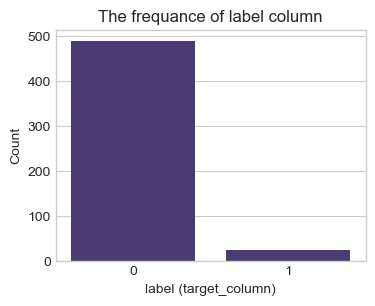

In [17]:
#plot the count chart to show the frequency of label column
plt.figure(figsize=(4,3))
sns.countplot(x=df.label)
plt.xlabel('label (target_column)')
plt.ylabel('Count')
plt.title('The frequance of label column')
plt.show()
          

>The target variable is highly imbalanced, with very few failure cases (label=1) compared to non-failures (label=0). This will make classification challenging, as standard models and accuracy metrics will likely be misleading. Special techniques for handling imbalanced data, as well as advanced metrics, are required to develop a useful predictive model in this context. we will solve this issue in data modeling section

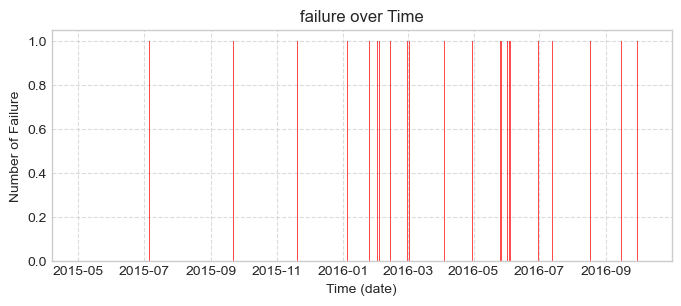

In [18]:
# 2- Plot failure over time
plt.figure(figsize=(8,3))
plt.bar(Label_date['date'],Label_date['label'],color='red',alpha=0.7)
plt.title ('failure over Time')
plt.xlabel('Time (date)')
plt.ylabel('Number of Failure')
plt.grid(True, linestyle='--', alpha =0.7)



>
>“The failure trend over time indicates a noticeable increase in machine failures between January and June 2016.
While most previous periods show either zero or isolated failure events, this specific interval demonstrates a clear uptick in the frequency of failures.
This pattern may suggest a period of operational stress, maintenance issues, or changes in machine usage.
Further investigation is needed to identify the root cause of this spike and determine if preventive measures can be implemented to avoid similar incidents in the future.”



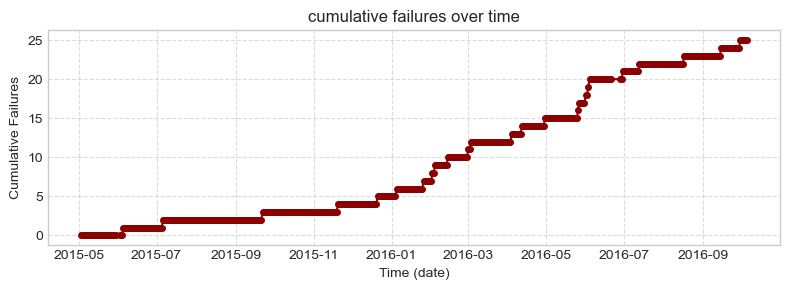

In [19]:
# Plot cumulative failure
plt.figure(figsize=(8,3))
plt.plot(Label_date['date'],Label_date['cumulative_failures'],color='darkred',marker='o',linestyle='-',markersize=4)
plt.title('cumulative failures over time')
plt.xlabel('Time (date)')        
plt.ylabel('Cumulative Failures')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


##  2- Multivariate Analysis.

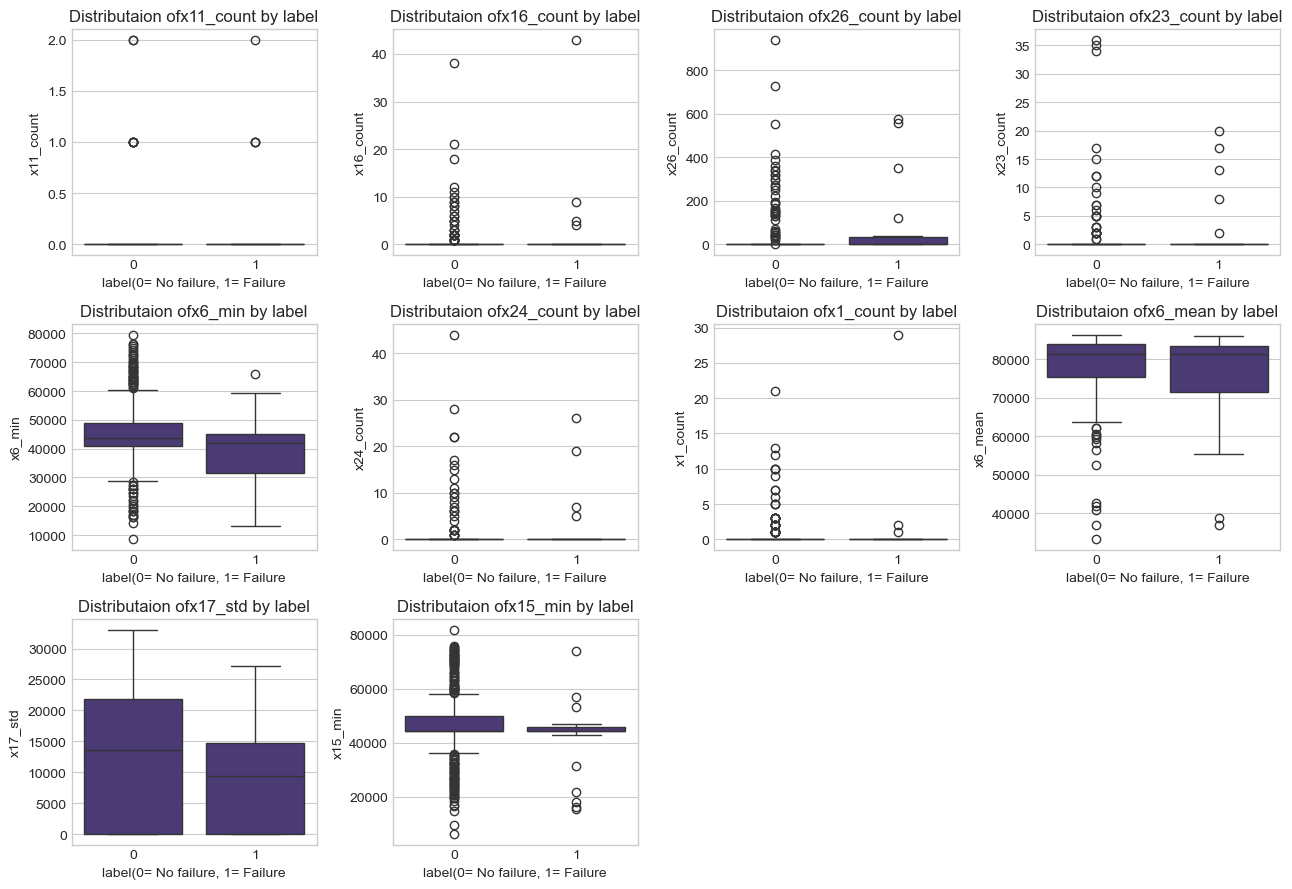

In [20]:
#Plot box plots of top count features
plt.figure(figsize=(13,9))
for i,feature in enumerate(top_numeric):
    plt.subplot(3,4,i+1)
    sns.boxplot(x='label',y=feature,data=df)
    plt.title(f'Distributaion of{feature} by label')
    plt.xlabel('label(0= No failure, 1= Failure')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

> 1- for **x11_count** feature the plot shows the distribution of  this feature . For both cases (0=non-failure , 1 =failure), the date is heavely concentrated at zero and has a zero median value for both. A few outliers are present in both groups. Over all the distribution for both are similar
> 
> 2- For **x16_count**  feature the plot displays that for both groups (0=non-failure , 1 =failure) this feature has zero median value and  avery small IQR, which indicates that most observations have zero count values. However, label 0 (No Failure) exhibits a significantly large number of outliers as well as a wider range of these outliers, extanding up to approximately 40. On the other hand, label 1 (Failure) has fewer outliers  reaching only up to 10 and a single outlier up to 40.
>   
> For **x26_count** feature the distribution for both groups are highly  right-skewed with most values concentrated near zero . The median on label 0 is very closed to zero . The median for label 1  appears slightly higher , and its IQR is wider than that of label 0 .Label 0 has more extreme outliers , with values reaching over 800, whereas outliers of label 1 reach up to 600
>  
> 3-**x6_min** (Minimum value of feature x6) This plot compares the distribution of the minimum value recorded for feature x6. There is a noticeable difference between the groups. Label 0 (Non-Failure) has a median minimum value around 45000, with an IQR from roughly 40000 to 50000.
Label 1 (Failure) has a significantly lower median minimum value, around 35000, and a wider IQR (approx. 25000 to 48000). Label 0 also has more
outliers, particularly low ones. This indicates that lower minimum values of x6 are strongly associated with the 'Failure' class.
>
> For **x17_std** feature there are a clear difference is visible  label 0 has a higher median  around 12000 and a wider IQR, approximately
 between (0 - 21000 ) compared of label 1 , which has a lower medien around 8000 and a narrower IQR (0-13000).

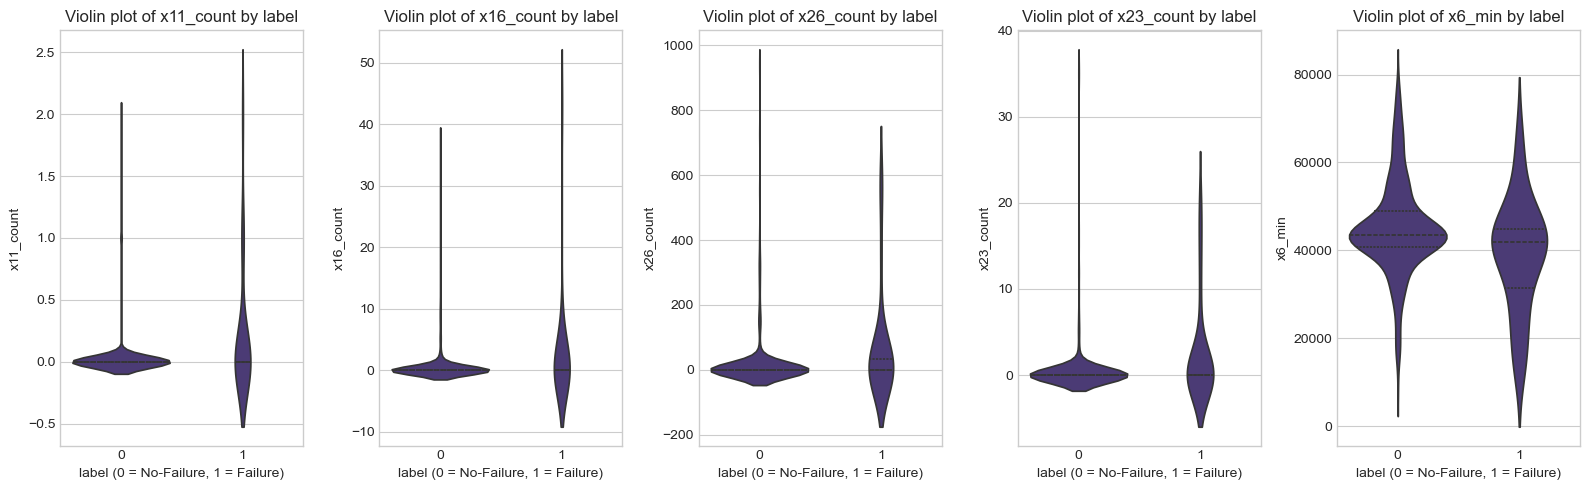

In [21]:
#Create a violin plot for top 5 features
plt.figure(figsize=(16,5))
for i , feature in enumerate (top_numeric[:5]):
    plt.subplot(1, 5, i+1)
    sns.violinplot(x='label', y = feature, data = df, inner='quartile')
    plt.title(f'Violin plot of {feature} by label')
    plt.xlabel('label (0 = No-Failure, 1 = Failure)')
plt.tight_layout()
plt.show()

> - The plot of **x11_count** shows that the probability density og this feature for both label 0 and label 1, the density is overwhelningly cocentrated at 0 for label 0 and -0.5 for label 1 . For label 0 it shows a slightly wider distribution near 0. Label 1 is much loger, though extremely thin , tail extending upwors(past 2.5), suggesting that while non-zero values are rare in bth groups , the few instances of higher counts are more likely to occure in the 'failure ' case.
>
> - the graph of **x6_min** displays the difference between the two labels. Label 0 shows the wider distribution centered around a higher value (approx.43000), with significant density spread both above and below this point . Label 1 shows a narrower distribution centered a lower value (aprox 35000-40000). The shape for label 1 suggest a highr  concentration  of lower minimum values compared to label 0 .

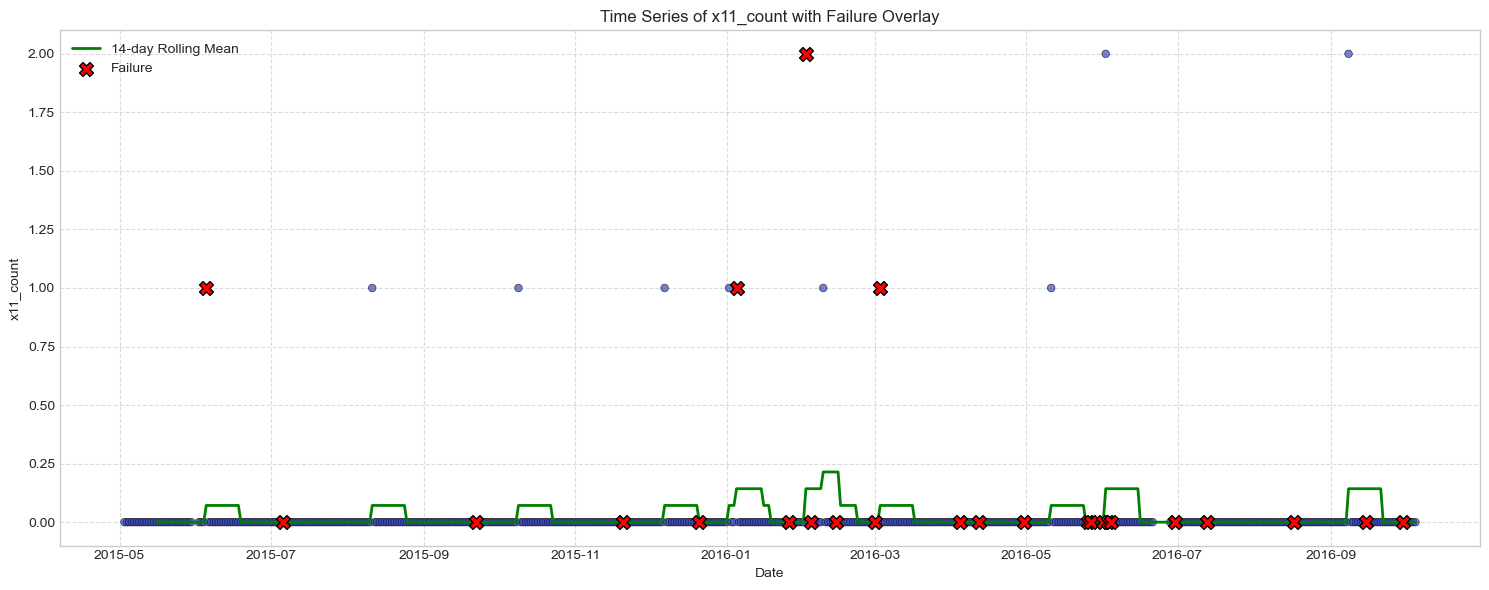

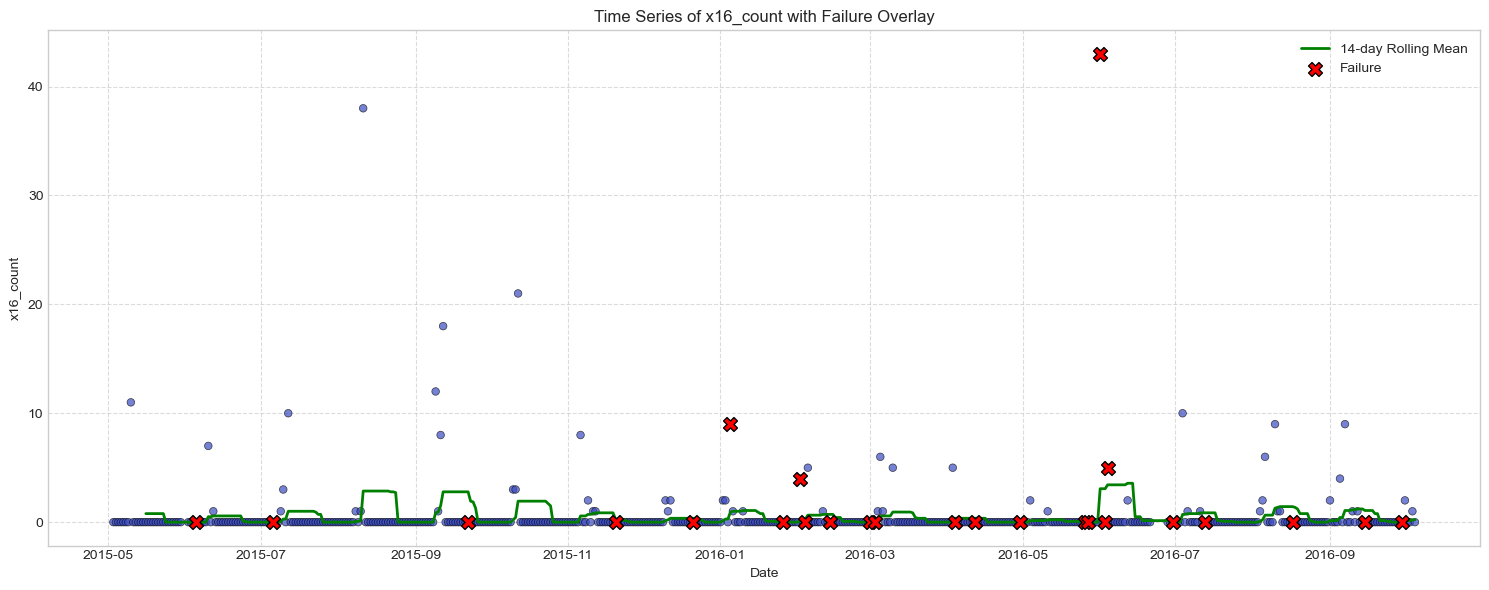

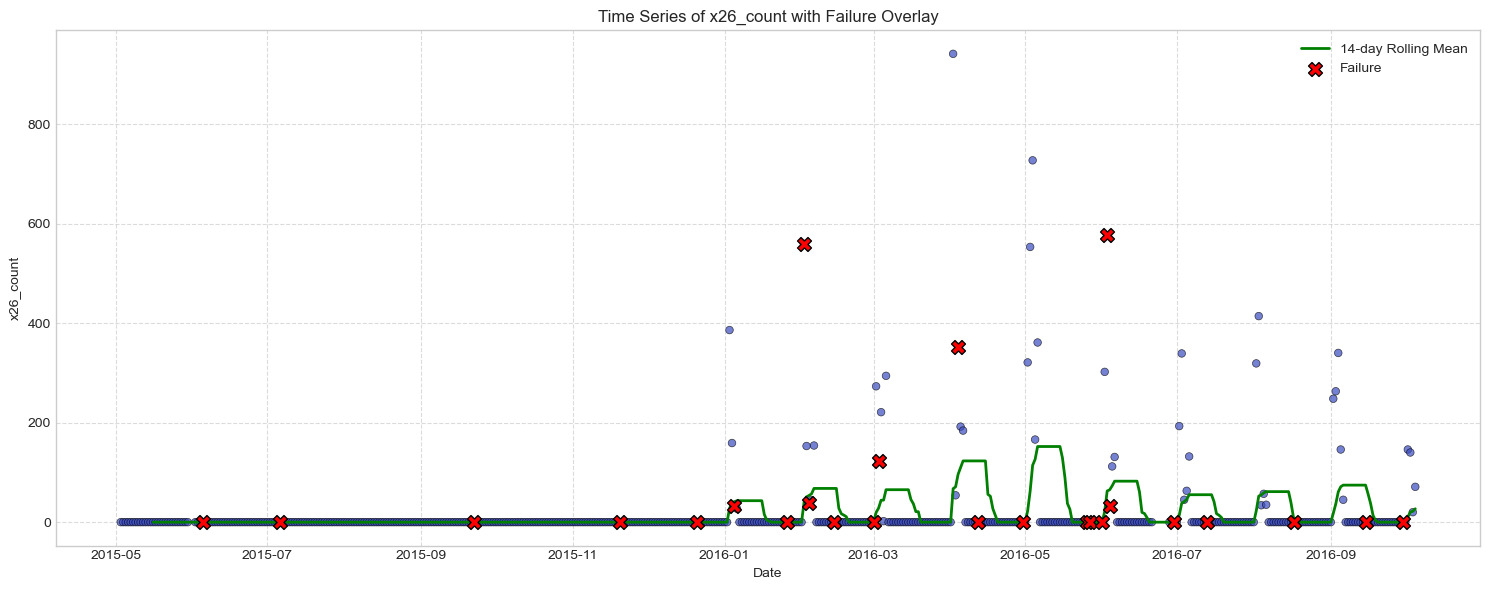

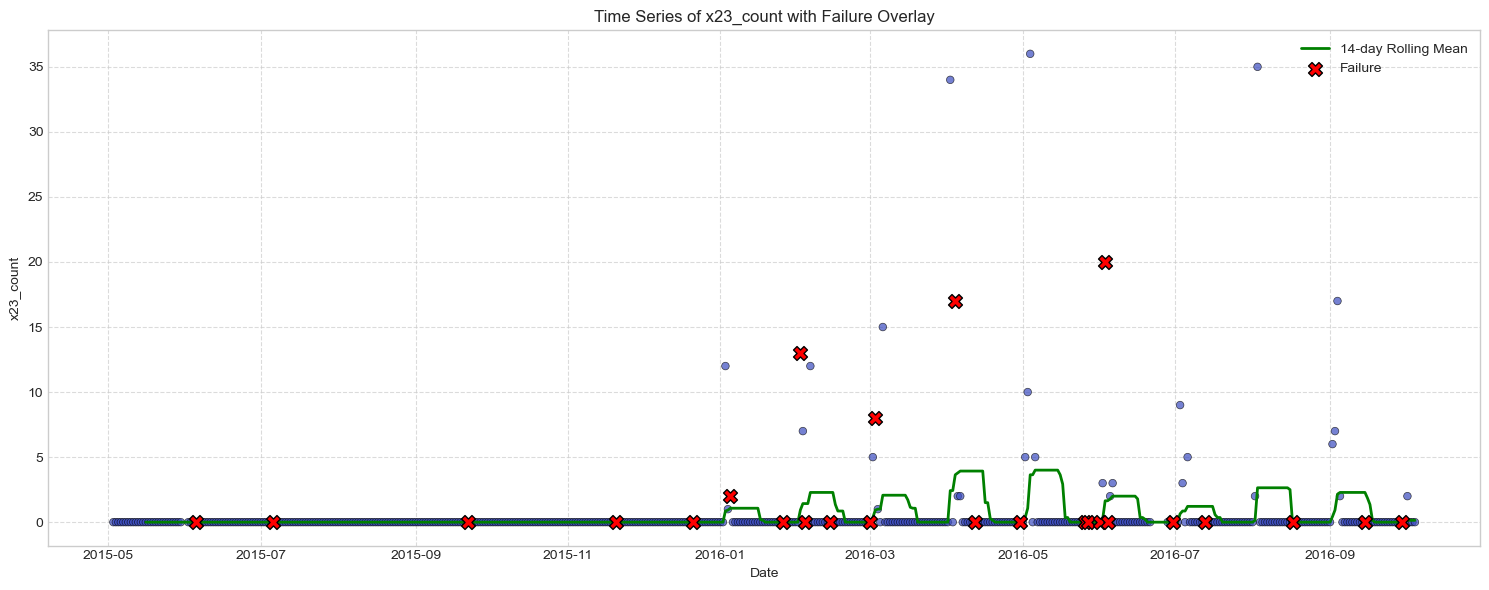

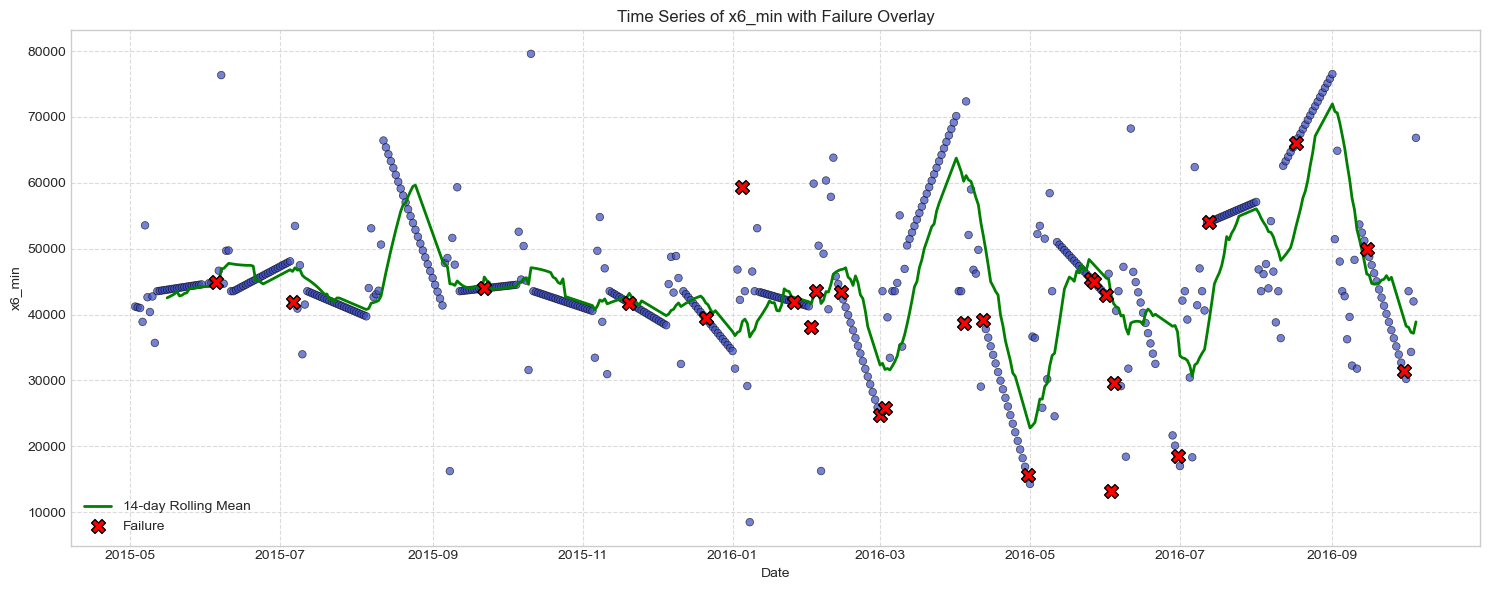

In [22]:
#Create a time series plots of top features with failure overtime
# Select top 5 features for time series analysis
top5_features = top_numeric[:5]

# Time Series Plots of Top Features with Failure Overlay
for feature in top5_features:
    plt.figure(figsize=(15, 6))
    
    # Create a scatter plot of the feature over time
    plt.scatter(df['date'], df[feature], c=df['label'], cmap='coolwarm', 
                alpha=0.7, s=30, edgecolors='k', linewidths=0.5)
    
    # Add a rolling mean line to show trend
    window_size = 14  # 14-day rolling window
    rolling_mean = df.set_index('date')[feature].rolling(window=window_size).mean()
    plt.plot(rolling_mean.index, rolling_mean.values, 'g-', linewidth=2, label=f'{window_size}-day Rolling Mean')
    
    # Highlight failure points
    failure_df = df[df['label'] == 1]
    plt.scatter(failure_df['date'], failure_df[feature], color='red', s=100, 
                marker='X', label='Failure', zorder=5, edgecolors='k')
    
    plt.title(f'Time Series of {feature} with Failure Overlay')
    plt.xlabel('Date')
    plt.ylabel(feature)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()


> 1- The first plot is about  **x11_count**, representing the failure points over time marked with a red marker. This analysis reveals
         >  - Most values concentrate at or near **zero**, with few elevated values reachinhg  1 or 2
        > - The rolling mean (green line) remains close to zero most of the time , with periodic slight elevation
        > -  While very high values **2** appear associated with failure, most of it don't show a clear pattern with **x11_count** , this indicator alone may not be reliable for failure prediction.
>          
> 2- For **x23_count** plot the key observation include:
       >- Most values concentrate at zero in the first half of the time period
       > - From January 2016 higher values begin to appear more frequently , with some peaks reaching up to 35.
       >- several failure events coincide with relatively high **x23_count** values (between 8 and 20)
       > -   The rolling mean shows perodic small elevations in the latter half of the period , and the prominent failure occurs at a value of about 20 in may 2016.
       > - Elevated values (particularly above 8) appear to correlate with increased  failure probability .This indicator could be  valuable as part of an early warning system , especailly when used in cojunction with other indicators.
>
> 3- For **x6_min**,  this plot highlighted  several important patterns that emerge:
       >  1- values generally range between 20000 and 70000, with clear fluctuatins throughout the period.
       > 2- sharp drops in values occur in March 2016 and MAy 2016 , falling below 25000.
       > 3- The rolling mean (green line) shows clear downward trends preceding many 
failure events, also many failure events (red markers) coincide with sharp decreases in x6_min values.
      >  4- Decreases in **x6_min values, particulary when falling below 30000, strongly correlate with increased failure probability. This indicator appears more reliable for failure prediction 


In [23]:
#Calculate correlation  matrix 
corr_matrix=df[top_numeric+['label']].corr()
#Create a mask for the upper triangle 
mask =np.triu(np.ones_like(corr_matrix, dtype=bool))

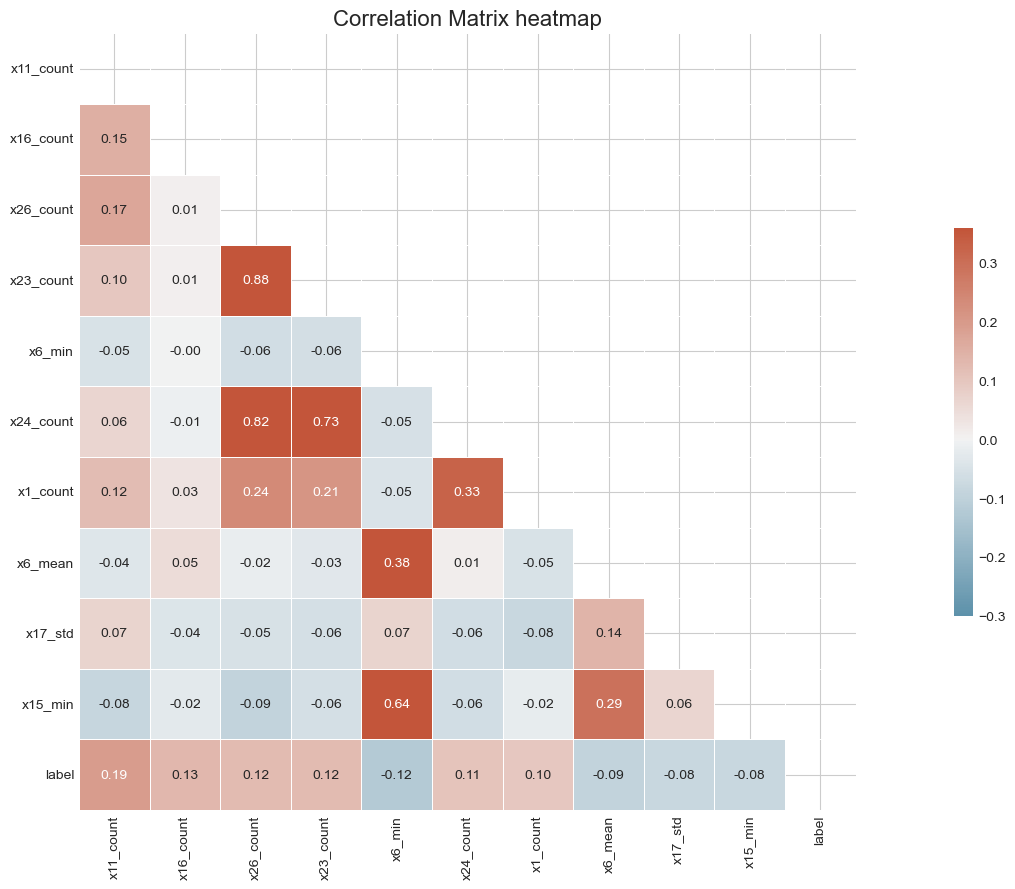

In [24]:
#Plot heatmap for the top 10 features with mask and correct aspect ratio
plt.figure(figsize=(20,9))
cmap= sns.diverging_palette(230,20,as_cmap=True)
sns.heatmap(corr_matrix, mask= mask, cmap= cmap,vmax=0.36, vmin=-0.3,center=0, square= True, linewidths=0.5,cbar_kws={'shrink':0.5}, annot=True,fmt=".2f")
plt.title('Correlation Matrix heatmap',fontsize=16)
plt.tight_layout()
           

> - The analysis identified x11_count, x16_count, x26_count, x23_count, and x6_min as the most influential features for failure prediction, with x11_count showing the strongest correlation (0.19) with failures

### In summary, this exploratory data analysis has demonstrated that failure prediction is feasible with this dataset, but requires careful feature engineering and appropriate modeling techniques to address the class imbalance. The visualizations has provided valuable insights into the underlying patterns and relationships, laying a solid foundation for developing an effective predictive model.